In [42]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [43]:
portfolio_tickers_sentiment =  pd.read_csv('data/v2tone_dataset.csv').round(2)
benchmark_sentiment = pd.read_csv('data/QQQ_2015_today.csv').round(2)
print(f"shape of portfolio_tickers_sentiment: {portfolio_tickers_sentiment.shape}")
print(f"columns of portfolio_tickers_sentiment: {portfolio_tickers_sentiment.columns}")
portfolio_tickers_sentiment.tail()

shape of portfolio_tickers_sentiment: (1316, 13)
columns of portfolio_tickers_sentiment: Index(['ticker', 'year', 'month', 'article_count', 'tone_mean',
       'positive_mean', 'negative_mean', 'finbert_sentiment',
       'confidence_level', 'sentiment_volatility', 'coverage_percentile',
       'sample_urls', 'sources_used'],
      dtype='object')


,ticker,year,month,article_count,tone_mean,positive_mean,negative_mean,finbert_sentiment,confidence_level,sentiment_volatility,coverage_percentile,sample_urls,sources_used
1311,VERU,2022,7,7,-1.27,3.32,4.59,-0.01,low,stable,0.00,[https://www.fool.com/investing/2022/07/11/why...,"[fool.com,marketwatch.com,thestreet.com]"
1312,VERU,2022,8,7,-1.35,2.28,3.63,-0.01,low,stable,0.00,[https://realmoney.thestreet.com/investing/sto...,"[thestreet.com,marketwatch.com,fool.com,busine..."
1313,VERU,2022,11,18,-1.96,2.51,4.47,-0.02,low,stable,1.00,[https://markets.businessinsider.com/news/stoc...,"[investors.com,marketwatch.com,businessinsider..."
1314,VERU,2022,12,8,-1.94,2.40,4.34,-0.02,low,stable,0.33,[https://markets.businessinsider.com/news/stoc...,"[fool.com,businessinsider.com,morningstar.com]"
1315,VERU,2023,3,12,-2.00,2.82,4.82,-0.02,low,stable,0.67,[https://www.morningstar.com/news/dow-jones/20...,"[marketwatch.com,morningstar.com,businessinsid..."


In [52]:
# Check data coverage period and identify any missing months
print("Data Coverage Analysis:")
print("=" * 50)

# Get date range for portfolio data
portfolio_dates = portfolio_tickers_sentiment[['year', 'month']].drop_duplicates().sort_values(['year', 'month'])
portfolio_start = f"{portfolio_dates.iloc[0]['year']}-{portfolio_dates.iloc[0]['month']:02d}"
portfolio_end = f"{portfolio_dates.iloc[-1]['year']}-{portfolio_dates.iloc[-1]['month']:02d}"

# Get date range for benchmark data  
benchmark_dates = benchmark_sentiment[['year', 'month']].drop_duplicates().sort_values(['year', 'month'])
benchmark_start = f"{benchmark_dates.iloc[0]['year']}-{benchmark_dates.iloc[0]['month']:02d}"
benchmark_end = f"{benchmark_dates.iloc[-1]['year']}-{benchmark_dates.iloc[-1]['month']:02d}"

print(f"Portfolio data period: {portfolio_start} to {portfolio_end}")
print(f"Benchmark data period: {benchmark_start} to {benchmark_end}")

# Create complete date range from 2015-01 to 2025-12
complete_dates = []
for year in range(2015, 2026):
    for month in range(1, 13):
        complete_dates.append({'year': year, 'month': month})
complete_df = pd.DataFrame(complete_dates)

# Check missing months in portfolio data
portfolio_missing = complete_df.merge(portfolio_dates, on=['year', 'month'], how='left', indicator=True)
portfolio_missing = portfolio_missing[portfolio_missing['_merge'] == 'left_only'][['year', 'month']]

# Check missing months in benchmark data
benchmark_missing = complete_df.merge(benchmark_dates, on=['year', 'month'], how='left', indicator=True)
benchmark_missing = benchmark_missing[benchmark_missing['_merge'] == 'left_only'][['year', 'month']]

print(f"\nPortfolio data covers {len(portfolio_dates)} months out of {len(complete_df)} possible months")
print(f"Missing months in portfolio data: {len(portfolio_missing)}")

print(f"\nBenchmark data covers {len(benchmark_dates)} months out of {len(complete_df)} possible months")
print(f"Missing months in benchmark data: {len(benchmark_missing)}")

if len(portfolio_missing) > 0:
    print(f"\nFirst 10 missing months in portfolio data:")
    print(portfolio_missing.head(10).to_string(index=False))

if len(benchmark_missing) > 0:
    print(f"\nFirst 10 missing months in benchmark data:")
    print(benchmark_missing.head(10).to_string(index=False))


Data Coverage Analysis:
Portfolio data period: 2015-02 to 2025-08
Benchmark data period: 2015-03 to 2025-07

Portfolio data covers 127 months out of 132 possible months
Missing months in portfolio data: 5

Benchmark data covers 78 months out of 132 possible months
Missing months in benchmark data: 54

First 10 missing months in portfolio data:
 year  month
 2015      1
 2025      9
 2025     10
 2025     11
 2025     12

First 10 missing months in benchmark data:
 year  month
 2015      1
 2015      2
 2015     10
 2016      1
 2016      3
 2016      4
 2017      2
 2017      3
 2017      4
 2017      5


In [44]:
col_to_keep = ['ticker', 'year', 'month', 'article_count', 'tone_mean', 'positive_mean', 'negative_mean']
portfolio_tickers_sentiment =  portfolio_tickers_sentiment[col_to_keep]
benchmark_sentiment = benchmark_sentiment[col_to_keep]
print(f"shape of benchmark_sentiment: {benchmark_sentiment.shape}")
benchmark_sentiment.tail()


shape of benchmark_sentiment: (78, 7)


,ticker,year,month,article_count,tone_mean,positive_mean,negative_mean
73,QQQ,2025,1,7,-0.48,2.16,2.64
74,QQQ,2025,3,14,-2.92,1.81,4.72
75,QQQ,2025,4,15,-0.20,2.33,2.53
76,QQQ,2025,5,9,0.86,2.83,1.97
77,QQQ,2025,7,13,1.17,3.41,2.24


In [45]:
benchmark_sentiment.columns

Index(['ticker', 'year', 'month', 'article_count', 'tone_mean',
       'positive_mean', 'negative_mean'],
      dtype='object')

In [46]:
# Concatenate horizontally (side by side)
combined_data = pd.concat([portfolio_tickers_sentiment, benchmark_sentiment], axis=0)
print(f"shape of combined_data: {combined_data.shape}")
combined_data = combined_data.sort_values(['year', 'month']).reset_index(drop=True)
combined_data.head()

shape of combined_data: (1394, 7)


,ticker,year,month,article_count,tone_mean,positive_mean,negative_mean
0,AEM,2015,2,9,1.01,2.65,1.64
1,GOOGL,2015,2,1208,-0.02,2.57,2.59
2,MRVL,2015,2,25,1.07,2.72,1.65
3,MSFT,2015,2,418,0.04,2.75,2.71
4,MU,2015,2,22,-0.25,1.56,1.81


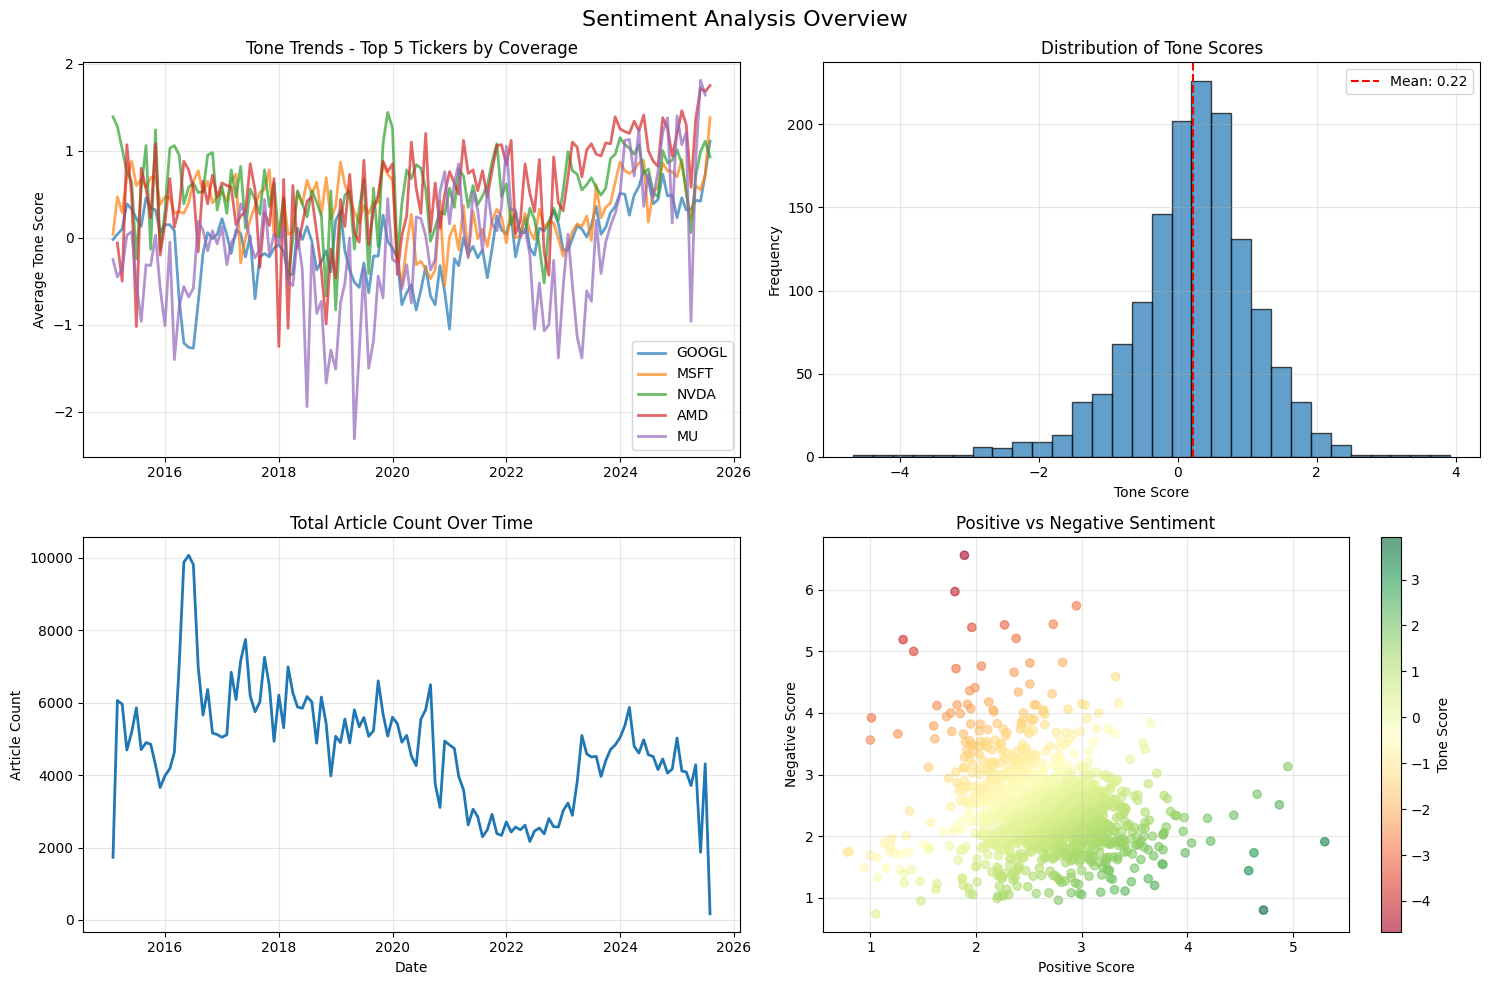

In [47]:
# Plot sentiment trends for each ticker over time
plt.style.use('default')
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Sentiment Analysis Overview', fontsize=16)

df = combined_data.copy()

# Plot 1: Tone trends over time for top tickers by article count
ax1 = axes[0, 0]
top_tickers = df.groupby('ticker')['article_count'].sum().nlargest(5).index
for ticker in top_tickers:
    ticker_data = df[df['ticker'] == ticker].copy()
    ticker_data['date'] = pd.to_datetime(ticker_data[['year', 'month']].assign(day=1))
    ax1.plot(ticker_data['date'], ticker_data['tone_mean'], label=ticker, alpha=0.7, linewidth=2)
ax1.set_title('Tone Trends - Top 5 Tickers by Coverage')
ax1.set_ylabel('Average Tone Score')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Distribution of tone scores
ax2 = axes[0, 1]
ax2.hist(df['tone_mean'], bins=30, alpha=0.7, edgecolor='black')
ax2.axvline(df['tone_mean'].mean(), color='red', linestyle='--', label=f'Mean: {df["tone_mean"].mean():.2f}')
ax2.set_title('Distribution of Tone Scores')
ax2.set_xlabel('Tone Score')
ax2.set_ylabel('Frequency')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Plot 3: Article count trends over time
ax3 = axes[1, 0]
monthly_articles = df.groupby(['year', 'month'])['article_count'].sum().reset_index()
monthly_articles['date'] = pd.to_datetime(monthly_articles[['year', 'month']].assign(day=1))
ax3.plot(monthly_articles['date'], monthly_articles['article_count'], linewidth=2)
ax3.set_title('Total Article Count Over Time')
ax3.set_ylabel('Article Count')
ax3.set_xlabel('Date')
ax3.grid(True, alpha=0.3)

# Plot 4: Positive vs Negative sentiment scatter
ax4 = axes[1, 1]
scatter = ax4.scatter(df['positive_mean'], df['negative_mean'], 
                     c=df['tone_mean'], cmap='RdYlGn', alpha=0.6)
ax4.set_xlabel('Positive Score')
ax4.set_ylabel('Negative Score')
ax4.set_title('Positive vs Negative Sentiment')
plt.colorbar(scatter, ax=ax4, label='Tone Score')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [48]:

# Fix the SettingWithCopyWarning by using .copy() and .loc
print("\nData Quality Check:")
print("=" * 50)

# Check for missing values
missing_data = df.isnull().sum()
print("Missing values per column:")
for col, count in missing_data.items():
    if count > 0:
        print(f"  {col}: {count} ({count/len(df)*100:.1f}%)")

# Check data types and ranges
print(f"\nTone score range: {df['tone_mean'].min():.2f} to {df['tone_mean'].max():.2f}")
print(f"positive_mean range: {df['positive_mean'].min():.2f} to {df['positive_mean'].max():.2f}")
print(f"negative_mean range: {df['negative_mean'].min():.2f} to {df['negative_mean'].max():.2f}")


# Summary statistics
print("Dataset Summary:")
print(f"Total tickers: {df['ticker'].nunique()}")
print(f"Date range: {df['year'].min()}-{df['month'][df['year'] == df['year'].min()].min()} to {df['year'].max()}-{df['month'][df['year'] == df['year'].max()].max()}")
print(f"Total articles: {df['article_count'].sum():,}")
print(f"Average tone: {df['tone_mean'].mean():.2f}")





Data Quality Check:
Missing values per column:

Tone score range: -4.67 to 3.92
positive_mean range: 0.78 to 5.30
negative_mean range: 0.74 to 6.56
Dataset Summary:
Total tickers: 20
Date range: 2015-2 to 2025-8
Total articles: 600,980
Average tone: 0.22


In [50]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import seaborn as sns

def prepare_data(portfolio_df, benchmark_df):
    """
    Prepare portfolio and benchmark data for comparison
    """
    print("Preparing data for validation...")
    
    # Aggregate portfolio by year/month (average across all assets)
    portfolio_agg = portfolio_df.groupby(['year', 'month'])[['tone_mean', 'positive_mean', 'negative_mean']].mean().reset_index()
    portfolio_agg.columns = ['year', 'month', 'portfolio_tone', 'portfolio_positive', 'portfolio_negative']
    
    # Get benchmark data (single asset QQQ)
    benchmark_agg = benchmark_df.groupby(['year', 'month'])[['tone_mean', 'positive_mean', 'negative_mean']].mean().reset_index()
    benchmark_agg.columns = ['year', 'month', 'benchmark_tone', 'benchmark_positive', 'benchmark_negative']
    
    # Merge by year and month
    aligned_data = pd.merge(portfolio_agg, benchmark_agg, on=['year', 'month'], how='inner')
    
    print(f"Portfolio data: {len(portfolio_agg)} months")
    print(f"Benchmark data: {len(benchmark_agg)} months")
    print(f"Aligned data: {len(aligned_data)} months")
    if len(aligned_data) > 0:
        print(f"Date range: {aligned_data['year'].min()}/{aligned_data['month'].min()} to {aligned_data['year'].max()}/{aligned_data['month'].max()}")
    
    return aligned_data

def test_correlations(aligned_data):
    """
    Test correlations for tone_mean, positive_mean, negative_mean
    """
    print(f"\n{'='*60}")
    print("CORRELATION TESTS: Portfolio vs Benchmark Sentiment")
    print(f"{'='*60}")
    
    metrics = [
        ('portfolio_tone', 'benchmark_tone', 'Tone Mean'),
        ('portfolio_positive', 'benchmark_positive', 'Positive Mean'),
        ('portfolio_negative', 'benchmark_negative', 'Negative Mean')
    ]
    
    results = {}
    
    for port_col, bench_col, name in metrics:
        print(f"\n--- {name} ---")
        
        # Get clean data (remove NaN)
        port_values = aligned_data[port_col].dropna()
        bench_values = aligned_data[bench_col].dropna()
        
        # Use only rows where both values exist
        mask = aligned_data[port_col].notna() & aligned_data[bench_col].notna()
        port_clean = aligned_data.loc[mask, port_col]
        bench_clean = aligned_data.loc[mask, bench_col]
        
        if len(port_clean) < 5:
            print(f"❌ Insufficient data: {len(port_clean)} observations")
            continue
        
        # Calculate correlation
        correlation, p_value = pearsonr(port_clean, bench_clean)
        r_squared = correlation ** 2
        
        # Store results
        results[name] = {
            'correlation': correlation,
            'p_value': p_value,
            'r_squared': r_squared,
            'sample_size': len(port_clean),
            'significant': p_value < 0.05,
            'portfolio_mean': np.mean(port_clean),
            'benchmark_mean': np.mean(bench_clean)
        }
        
        # Display results
        print(f"Sample size: {len(port_clean)} months")
        print(f"Correlation: {correlation:.4f}")
        print(f"P-value: {p_value:.4f}")
        print(f"R-squared: {r_squared:.4f} ({r_squared*100:.1f}% variance explained)")
        print(f"Significant: {'✅ YES' if p_value < 0.05 else '❌ NO'}")
        print(f"Portfolio mean: {np.mean(port_clean):.3f}")
        print(f"Benchmark mean: {np.mean(bench_clean):.3f}")
    
    return results

def create_plots(aligned_data, results):
    """
    Create simple validation plots
    """
    print(f"\n📊 Creating validation plots...")
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    metrics = [
        ('portfolio_tone', 'benchmark_tone', 'Tone Mean', 'Tone Mean'),
        ('portfolio_positive', 'benchmark_positive', 'Positive Mean', 'Positive Mean'), 
        ('portfolio_negative', 'benchmark_negative', 'Negative Mean', 'Negative Mean')
    ]
    
    for i, (port_col, bench_col, title, result_key) in enumerate(metrics):
        ax = axes[i]
        
        # Get clean data
        mask = aligned_data[port_col].notna() & aligned_data[bench_col].notna()
        
        if mask.sum() > 0:
            port_clean = aligned_data.loc[mask, port_col]
            bench_clean = aligned_data.loc[mask, bench_col]
            
            # Scatter plot
            ax.scatter(bench_clean, port_clean, alpha=0.6)
            
            # Trend line
            z = np.polyfit(bench_clean, port_clean, 1)
            p = np.poly1d(z)
            ax.plot(bench_clean, p(bench_clean), "r--", alpha=0.8)
            
            ax.set_xlabel(f'Benchmark {title}')
            ax.set_ylabel(f'Portfolio {title}')
            ax.set_title(f'{title} Correlation')
            
            # Add correlation info
            if result_key in results:
                corr = results[result_key]['correlation']
                pval = results[result_key]['p_value']
                ax.text(0.05, 0.95, f'r = {corr:.3f}\np = {pval:.4f}', 
                       transform=ax.transAxes, verticalalignment='top',
                       bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    plt.tight_layout()
    plt.show()

def interpret_results(results):
    """
    Provide simple interpretation and recommendation
    """
    print(f"\n{'='*60}")
    print("VALIDATION RESULTS & RECOMMENDATION")
    print(f"{'='*60}")
    
    significant_metrics = [name for name, res in results.items() if res['significant']]
    strong_correlations = [name for name, res in results.items() if abs(res['correlation']) > 0.3]
    
    print(f"\n📊 SUMMARY:")
    print(f"   Total metrics tested: {len(results)}")
    print(f"   Statistically significant: {len(significant_metrics)}")
    print(f"   Strong correlations (>0.3): {len(strong_correlations)}")
    
    print(f"\n📋 DETAILED RESULTS:")
    for name, res in results.items():
        status = "✅ GOOD" if res['significant'] and abs(res['correlation']) > 0.2 else "❌ WEAK"
        print(f"   {name}: r={res['correlation']:.3f}, p={res['p_value']:.4f} {status}")
    
    # Overall recommendation
    print(f"\n🎯 RECOMMENDATION FOR HARLF:")
    
    if len(significant_metrics) >= 2 and len(strong_correlations) >= 1:
        print(f"   ✅ YOUR GDELT SENTIMENT DATA IS MEANINGFUL")
        print(f"   ✅ Proceed with sentiment integration in HARLF")
        print(f"   ✅ Expected improvement over metrics-only approach")
        print(f"   📈 Focus on: {', '.join(significant_metrics)}")
    
    elif len(significant_metrics) >= 1:
        print(f"   🔶 YOUR GDELT SENTIMENT DATA HAS SOME VALUE") 
        print(f"   🔶 Proceed with caution - use sentiment weighting")
        print(f"   🔶 Consider data smoothing or filtering")
        print(f"   📈 Useful metrics: {', '.join(significant_metrics)}")
    
    else:
        print(f"   ❌ YOUR GDELT SENTIMENT DATA IS NOT MEANINGFUL")
        print(f"   ❌ Poor correlation with benchmark sentiment")
        print(f"   ❌ Consider alternative sentiment sources")
        print(f"   ❌ Or proceed with metrics-only HARLF")
    
    return len(significant_metrics) >= 1

def validate_sentiment_data(portfolio_sentiment_df, benchmark_sentiment_df):
    """
    Main function to validate portfolio sentiment vs benchmark sentiment
    
    Args:
        portfolio_sentiment_df: Your portfolio sentiment data
        benchmark_sentiment_df: Your QQQ benchmark sentiment data
    
    Returns:
        is_valid: True if sentiment data is meaningful, False otherwise
    """
    print("="*60)
    print("PORTFOLIO vs BENCHMARK SENTIMENT VALIDATION")
    print("="*60)
    print(f"Portfolio data shape: {portfolio_sentiment_df.shape}")
    print(f"Benchmark data shape: {benchmark_sentiment_df.shape}")
    
    # 1. Prepare data
    aligned_data = prepare_data(portfolio_sentiment_df, benchmark_sentiment_df)
    
    # 2. Test correlations
    results = test_correlations(aligned_data)
    
    # 3. Create plots
    create_plots(aligned_data, results)
    
    # 4. Interpret results
    is_valid = interpret_results(results)
    
    print(f"\n{'='*60}")
    print(f"FINAL RESULT: {'SENTIMENT DATA IS VALID ✅' if is_valid else 'SENTIMENT DATA IS INVALID ❌'}")
    print(f"{'='*60}")
    
    return is_valid, results


PORTFOLIO vs BENCHMARK SENTIMENT VALIDATION
Portfolio data shape: (1316, 7)
Benchmark data shape: (78, 7)
Preparing data for validation...
Portfolio data: 127 months
Benchmark data: 78 months
Aligned data: 78 months
Date range: 2015/1 to 2025/12

CORRELATION TESTS: Portfolio vs Benchmark Sentiment

--- Tone Mean ---
Sample size: 78 months
Correlation: 0.2942
P-value: 0.0089
R-squared: 0.0865 (8.7% variance explained)
Significant: ✅ YES
Portfolio mean: 0.259
Benchmark mean: -0.143

--- Positive Mean ---
Sample size: 78 months
Correlation: 0.4699
P-value: 0.0000
R-squared: 0.2208 (22.1% variance explained)
Significant: ✅ YES
Portfolio mean: 2.693
Benchmark mean: 2.044

--- Negative Mean ---
Sample size: 78 months
Correlation: 0.2639
P-value: 0.0196
R-squared: 0.0696 (7.0% variance explained)
Significant: ✅ YES
Portfolio mean: 2.434
Benchmark mean: 2.188

📊 Creating validation plots...


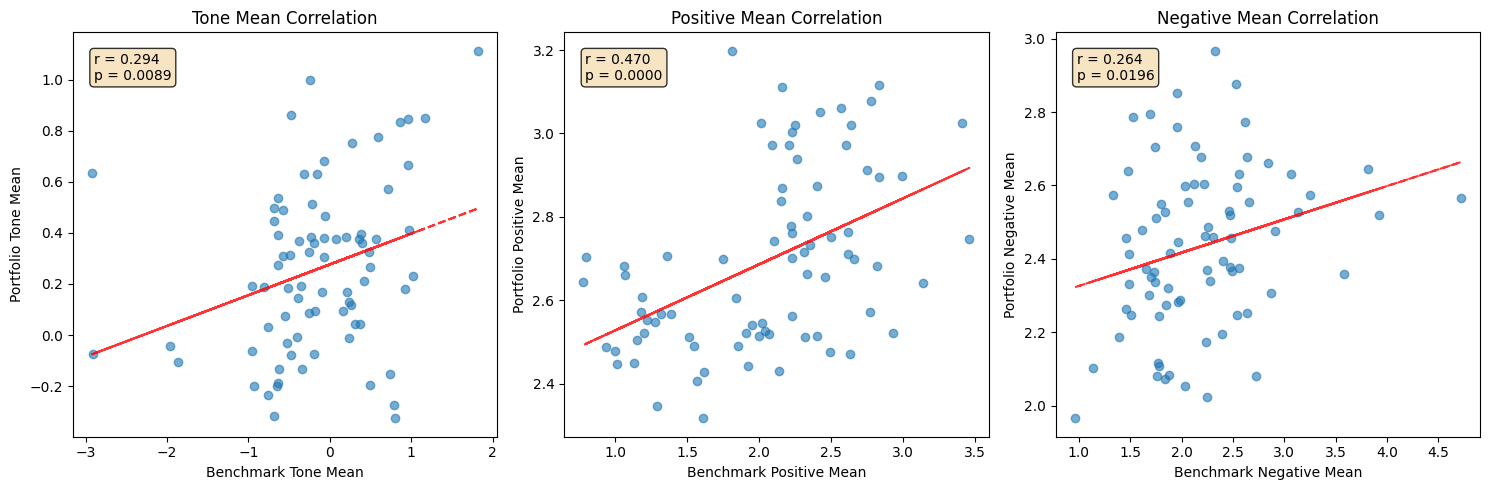


VALIDATION RESULTS & RECOMMENDATION

📊 SUMMARY:
   Total metrics tested: 3
   Statistically significant: 3
   Strong correlations (>0.3): 1

📋 DETAILED RESULTS:
   Tone Mean: r=0.294, p=0.0089 ✅ GOOD
   Positive Mean: r=0.470, p=0.0000 ✅ GOOD
   Negative Mean: r=0.264, p=0.0196 ✅ GOOD

🎯 RECOMMENDATION FOR HARLF:
   ✅ YOUR GDELT SENTIMENT DATA IS MEANINGFUL
   ✅ Proceed with sentiment integration in HARLF
   ✅ Expected improvement over metrics-only approach
   📈 Focus on: Tone Mean, Positive Mean, Negative Mean

FINAL RESULT: SENTIMENT DATA IS VALID ✅
✅ Your GDELT sentiment correlates with benchmark - use in HARLF


In [51]:
# Your data is ready as-is:
# portfolio_tickers_sentiment has columns: ticker, year, month, article_count, tone_mean, positive_mean, negative_mean
# benchmark_sentiment has columns: ticker, year, month, article_count, tone_mean, positive_mean, negative_mean

# Just run:
is_valid, results = validate_sentiment_data(
    portfolio_tickers_sentiment,  # Your portfolio sentiment data
    benchmark_sentiment          # Your QQQ benchmark sentiment data  
)

# Get your answer:
if is_valid:
    print("✅ Your GDELT sentiment correlates with benchmark - use in HARLF")
else:
    print("❌ Your GDELT sentiment doesn't correlate - skip sentiment")